In [ ]:
import os
import time
import random
from pathlib import Path
import tqdm
import numpy as np
import torch
import sklearn
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score, recall_score
import transformers
import datasets
from datasets import Dataset

from src.models.baseline_model import BaselineModel
from src.models.transformer_model import TransformerModel
from src.models.knn_classifier import KNNClassifier
from src.models.hybrid_classifier import HybridClassifier
from src.models.summarizer import Summarizer
from src.utils.lyrics_data_processor import LyricsDataProcessor

import matplotlib.pyplot as plt

MEASURE_TIME = True
if MEASURE_TIME:
    notebook_start = time.time()


# Deshabilitar WanDB
os.environ["WANDB_DISABLED"] = "true"

print("- Versiones de librerías utilizadas:")
print(f"    - NumPy: {np.__version__}")
print(f"    - PyTorch: {torch.__version__}")
print(f"    - transformers: {transformers.__version__}")
print(f"    - datasets: {datasets.__version__}")
print(f"    - scikit-learn: {sklearn.__version__}")

- Versiones de librerías utilizadas:
    - NumPy: 2.2.6
    - PyTorch: 2.9.0+cu128
    - transformers: 4.57.1
    - datasets: 4.4.2
    - scikit-learn: 1.7.2


In [2]:
# Semilla
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"- Semilla utilizada: {SEED}")

- Semilla utilizada: 42


In [3]:
# Parámetros
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"- Dispositivo para PyTorch: {DEVICE}")

# Directorios
DATA_DIR = Path("data")
os.makedirs(DATA_DIR, exist_ok=True)
GENERATED_DATA_DIR = DATA_DIR / "generated"
os.makedirs(GENERATED_DATA_DIR, exist_ok=True)
DATASETS_TRANSFORMER = {
    "train": Path(DATA_DIR / "train_dataset_transformer"),
    "eval": Path(DATA_DIR / "eval_dataset_transformer"),
    "test": Path(DATA_DIR / "test_dataset_transformer")
}
DATASETS_BASELINE = {
    "train": (Path(DATA_DIR / "X_train_baseline.npz"), Path(DATA_DIR / "y_train.npy")),
    "eval": (Path(DATA_DIR / "X_eval_baseline.npz"), Path(DATA_DIR / "y_eval.npy")),
    "test": (Path(DATA_DIR / "X_test_baseline.npz"), Path(DATA_DIR / "y_test.npy"))
}
EMBEDDINGS = {
    "train": Path(GENERATED_DATA_DIR / "train_embeddings.npy"),
    "eval": Path(GENERATED_DATA_DIR / "eval_embeddings.npy"),
    "test": Path(GENERATED_DATA_DIR / "test_embeddings.npy")
}
MODELS_DIR = Path("models")
os.makedirs(MODELS_DIR, exist_ok=True)
TEACHER_MODEL_PATH = MODELS_DIR / "transformer"  # Modelo Transformer de la práctica 1 (teacher en la práctica 2)
BASELINE_MODEL_PATH = MODELS_DIR / "baseline_model"  # Modelo baseline de la práctica 1
STUDENT_MODEL_PATH = MODELS_DIR / "student_transformer"  # Modelo Transformer student

print(f"- Directorios establecidos:")
print(f"    - DATA_DIR: {str(DATA_DIR)}")
print(f"    - GENERATED_DATA_DIR: {str(GENERATED_DATA_DIR)}")
print(f"    - MODELS_DIR: {str(MODELS_DIR)}")
print(f"        - TEACHER_MODEL: {str(TEACHER_MODEL_PATH)} --> {'Existe' if TEACHER_MODEL_PATH.exists() else 'No existe'}")
print(f"        - BASELINE_MODEL: {str(BASELINE_MODEL_PATH)} --> {'Existe' if BASELINE_MODEL_PATH.exists() else 'No existe'}")
print(f"        - STUDENT_MODEL: {str(STUDENT_MODEL_PATH)} --> {'Existe' if STUDENT_MODEL_PATH.exists() else 'No existe'}")
print(f"    - DATASETS_TRANSFORMER: {dict(map(lambda x: (x, str(DATASETS_TRANSFORMER[x])), DATASETS_TRANSFORMER))}")
print(f"    - DATASETS_BASELINE: {dict(map(lambda x: (x, (str(DATASETS_BASELINE[x][0]), str(DATASETS_BASELINE[x][1]))), DATASETS_BASELINE))}")
print(f"    - EMBEDDINGS: {dict(map(lambda x: (x, str(EMBEDDINGS[x])), EMBEDDINGS))}")

- Dispositivo para PyTorch: cuda
- Directorios establecidos:
    - DATA_DIR: data
    - GENERATED_DATA_DIR: data/generated
    - MODELS_DIR: models
        - TEACHER_MODEL: models/transformer --> Existe
        - BASELINE_MODEL: models/baseline_model --> No existe
        - STUDENT_MODEL: models/student_transformer --> Existe
    - DATASETS_TRANSFORMER: {'train': 'data/train_dataset_transformer', 'eval': 'data/eval_dataset_transformer', 'test': 'data/test_dataset_transformer'}
    - DATASETS_BASELINE: {'train': ('data/X_train_baseline.npz', 'data/y_train.npy'), 'eval': ('data/X_eval_baseline.npz', 'data/y_eval.npy'), 'test': ('data/X_test_baseline.npz', 'data/y_test.npy')}
    - EMBEDDINGS: {'train': 'data/generated/train_embeddings.npy', 'eval': 'data/generated/eval_embeddings.npy', 'test': 'data/generated/test_embeddings.npy'}


In [4]:
# Comprobamos la existencia de los datos
for split in ["train", "eval", "test"]:
    assert DATASETS_TRANSFORMER[split].exists(), f"El conjunto de datos {split} para el modelo Transformer no existe."
    assert DATASETS_BASELINE[split][0].exists(), f"El conjunto de datos {split} para el modelo baseline no existe."
    assert DATASETS_BASELINE[split][1].exists(), f"El conjunto de etiquetas {split} para el modelo baseline no existe."

In [5]:
# Comprobamos la existencia de los embeddings generados
for split, path in EMBEDDINGS.items():
    if not path.exists():
        EMBEDDINGS[split] = None
        print(f"- Los embeddings para el conjunto {split} no existen.")
    else:
        print(f"- Los embeddings para el conjunto {split} existen.")

- Los embeddings para el conjunto train existen.
- Los embeddings para el conjunto eval existen.
- Los embeddings para el conjunto test existen.


# Procesamiento del Lenguaje Natural 2 - Práctica 2
## 1. Módulo de *retrieval* denso
### 1.1. Construcción del índice:
- Utilizamos el conjunto de entrenamiento de la práctica 1 como corpus.

In [6]:
# Datos preparados para el modelo Transformer
train_dataset_transformer = LyricsDataProcessor.load_dataset_transformer(DATA_DIR / "train_dataset_transformer")
eval_dataset_transformer = LyricsDataProcessor.load_dataset_transformer(DATA_DIR / "eval_dataset_transformer")
test_dataset_transformer = LyricsDataProcessor.load_dataset_transformer(DATA_DIR / "test_dataset_transformer")

# Datos preparados para el modelo baseline
X_train_baseline = LyricsDataProcessor.load_data_baseline(DATA_DIR / "X_train_baseline.npz")
y_train_baseline = LyricsDataProcessor.load_label(DATA_DIR / "y_train.npy")
X_eval_baseline = LyricsDataProcessor.load_data_baseline(DATA_DIR / "X_eval_baseline.npz")
y_eval_baseline = LyricsDataProcessor.load_label(DATA_DIR / "y_eval.npy")
X_test_baseline = LyricsDataProcessor.load_data_baseline(DATA_DIR / "X_test_baseline.npz")
y_test_baseline = LyricsDataProcessor.load_label(DATA_DIR / "y_test.npy")

### 1.2. Función de *embedding*: 
- `embed_fn(texts)` usando el *encoder* del modelo Transformer de la práctica 1 (sin la capa de clasificación) para obtener vectores $d$-dimensionales.

In [7]:
def embed_fn(transformer_model, texts, device):
    embeddings = []
    for text_id in tqdm.tqdm(range(len(texts)), desc="Obteniendo embeddings"):
        input_ids = torch.tensor(texts[text_id]["input_ids"]).to(device)
        attention_mask = torch.tensor(texts[text_id]["attention_mask"]).to(device)

        inputs = {"input_ids": input_ids.unsqueeze(0), "attention_mask": attention_mask.unsqueeze(0)}

        with torch.no_grad():
            outputs = transformer_model._model(**inputs, output_hidden_states=True)
            e = outputs.hidden_states[-1][:, 0, :]

        embeddings.append(e.cpu().numpy())

    return np.vstack(embeddings)

In [8]:
# Cargamos el modelo Transformer preentrenado
LABEL2ID = {
    "rap": 0,
    "rock": 1,
    "pop": 2,
    "other": 3
}
ID2LABEL = {
    0: "rap",
    1: "rock",
    2: "pop",
    3: "other"
}
teacher_model = TransformerModel.load_model(
    path=MODELS_DIR / "transformer",
    label2id=LABEL2ID,
    id2label=ID2LABEL
)

- Cargando modelo desde models/transformer...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


### 1.3. Índice k-NN
- Construir un índice (por ejemplo, con `sklearn.NearestNeighbors` y métrica coseno).

In [9]:
# Construir índice k-NN con métrica coseno
N_NEIGHBORS = 5
nearest_neighbors = NearestNeighbors(n_neighbors=N_NEIGHBORS, metric="cosine")

# Obtener embeddings del conjunto de entrenamiento
if EMBEDDINGS["train"] is None:
    train_embeddings = embed_fn(teacher_model, train_dataset_transformer, DEVICE)
    np.save(GENERATED_DATA_DIR / "train_embeddings.npy", train_embeddings)
else:
    train_embeddings = np.load(EMBEDDINGS["train"])

# Obtener embeddings del conjunto de evaluación
if EMBEDDINGS["eval"] is None:
    eval_embeddings = embed_fn(teacher_model, eval_dataset_transformer, DEVICE)
    np.save(GENERATED_DATA_DIR / "eval_embeddings.npy", eval_embeddings)
else:
    eval_embeddings = np.load(EMBEDDINGS["eval"])

# Obtener embeddings del conjunto de test
if EMBEDDINGS["test"] is None:
    test_embeddings = embed_fn(teacher_model, test_dataset_transformer, DEVICE)
    np.save(GENERATED_DATA_DIR / "test_embeddings.npy", test_embeddings)
else:
    test_embeddings = np.load(EMBEDDINGS["test"])

In [10]:
# Ajustar el índice con los embeddings
nearest_neighbors.fit(train_embeddings)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


### 1.4. Búsqueda
- Definir `search(query_texts, k)` para devolver:
    - Los $k$ vecinos más cercanos
    - La distancia/similitud.
    - Metadatos asociados (texto original, etiqueta).


In [11]:
def search(
        nearest_neighbors: NearestNeighbors,
        transformer_model: TransformerModel,
        knn_dataset: Dataset | dict,
        query_texts: Dataset | dict | None = None,
        embeddings: np.ndarray | None = None,
        k: int = 5,
        device: torch.device = torch.device("cpu")
    ) -> tuple[np.ndarray, np.ndarray, list[str], list[int]]:
    if query_texts is None and embeddings is None:
        raise ValueError("Se debe proporcionar 'query_texts' o 'embeddings'.")

    query_embeddings = embeddings if embeddings is not None else embed_fn(transformer_model, query_texts, device)
    distances, indices = nearest_neighbors.kneighbors(query_embeddings, n_neighbors=k)

    texts = []
    labels = []
    for row_indices in indices:
        texts.append([knn_dataset[i]["text"] for i in row_indices])
        labels.append([knn_dataset[i]["label"] for i in row_indices])

    return distances, indices, texts, labels

### 1.5. Evaluación básica
- Calcular Precision@k y/o Recall@k de los vecinos que tienen la misma etiqueta que el ejemplo objetivo.

In [12]:
# Obtenemos un ejemplo aleatorio del conjunto de evaluación
example_idx = random.randint(0, len(eval_dataset_transformer) - 1)
example = eval_dataset_transformer[example_idx]

# Realizamos la búsqueda
query_texts = [example]
query_label = example["label"]
distances, indices, texts, labels = search(
    query_texts=query_texts,
    nearest_neighbors=nearest_neighbors,
    k=N_NEIGHBORS,
    transformer_model=teacher_model,
    device=DEVICE,
    knn_dataset=train_dataset_transformer
)

print(f"- Ejemplo de consulta (índice {example_idx} del conjunto de evaluación):")
print(f"    - Texto: {example['text'][:100]}...")
print(f"    - Etiqueta verdadera: {query_label}")
print(f"    - Vecinos más cercanos encontrados:")
for i in range(N_NEIGHBORS):
    print(f"        - Vecino {i+1}:")
    print(f"            - Distancia: {distances[0][i]:.4f}")
    print(f"            - Texto: {texts[0][i][:100]}...")
    print(f"            - Etiqueta: {labels[0][i]}")

Obteniendo embeddings: 100%|██████████| 1/1 [00:00<00:00,  4.76it/s]


- Ejemplo de consulta (índice 41905 del conjunto de evaluación):
    - Texto: Bells ringing inside my head
Now, I could ignore them
But I choose to live instead
So I take up into...
    - Etiqueta verdadera: 2
    - Vecinos más cercanos encontrados:
        - Vecino 1:
            - Distancia: 0.0125
            - Texto: Stripped to the waist
We fall into the river
Cover your eyes
So you don't know the secret
I've been ...
            - Etiqueta: 2
        - Vecino 2:
            - Distancia: 0.0136
            - Texto: I don't wanna walk away
But I can't stay how you say I should be
I won't break
But I can't bend enou...
            - Etiqueta: 2
        - Vecino 3:
            - Distancia: 0.0146
            - Texto: I'm freaking out
Yeah, yeah
I'm standing in the heart of nowhere
Futility's forgotten soldier
The da...
            - Etiqueta: 2
        - Vecino 4:
            - Distancia: 0.0147
            - Texto: Cause I use to live
In a fuzzy dream
And I wanted to be
Like all the

In [13]:
test_distances, test_indices, test_texts, test_labels = search(
    embeddings=test_embeddings,
    nearest_neighbors=nearest_neighbors,
    k=N_NEIGHBORS,
    transformer_model=teacher_model,
    device=DEVICE,
    knn_dataset=train_dataset_transformer
)

# Precomputar el conteo de ejemplos por clase en el conjunto de entrenamiento
class_counts = {}
for j in range(len(train_dataset_transformer)):
    label = train_dataset_transformer[j]["label"]
    class_counts[label] = class_counts.get(label, 0) + 1

# Calcular Precision@k y Recall@k para cada ejemplo de test
precision_at_k = []
recall_at_k = []

for i, test_label in enumerate(test_labels):
    query_label = y_test_baseline[i]
    
    # Precision@k: fracción de los k vecinos que tienen la etiqueta correcta
    relevant_neighbors = sum(1 for label in test_label if label == query_label)
    prec_k = relevant_neighbors / N_NEIGHBORS
    precision_at_k.append(prec_k)

    # Recall@k: fracción de los ejemplos relevantes encontrados en los k vecinos
    total_relevant_in_train = class_counts.get(query_label, 0)
    rec_k = relevant_neighbors / total_relevant_in_train if total_relevant_in_train > 0 else 0
    recall_at_k.append(rec_k)

# Calcular promedios
avg_precision_at_k = np.mean(precision_at_k)
avg_recall_at_k = np.mean(recall_at_k)

print(f"- Precision@{N_NEIGHBORS}: {avg_precision_at_k:.4f}")
print(f"- Recall@{N_NEIGHBORS}: {avg_recall_at_k:.4f}")
print(f"- Número de ejemplos de test evaluados: {len(test_labels)}")

- Precision@5: 0.7834
- Recall@5: 0.0001
- Número de ejemplos de test evaluados: 47638


## 2. Clasificador k-NN sobre *embeddings*
### 2.1. Definición del clasificador
- Implementar un clasificador que obtenga el embedding del texto, recupere los top−k vecinos de entrenamiento y prediga la clase mediante voto mayoritario de las etiquetas de los vecinos.

### 2.2. Evaluación
- Medir el rendimiento (Accuracy y Macro-F1) usando la misma partición de datos (train/dev/test) que en la práctica 1.

In [14]:
knn_classifier = KNNClassifier(teacher_model, DEVICE, N_NEIGHBORS)
knn_classifier.fit(train_dataset_transformer, train_embeddings)
knn_eval_indices, knn_eval_predictions = knn_classifier.predict(embeddings=eval_embeddings)

accuracy_eval_knn = accuracy_score(y_eval_baseline, knn_eval_predictions)
macrof1_eval_knn = f1_score(y_eval_baseline, knn_eval_predictions, average="macro")
perclassf1_eval_knn = f1_score(y_eval_baseline, knn_eval_predictions, average=None)
print("- Resultados del clasificador k-NN con el conjunto de evaluación:")
print(f"    - Accuracy: {accuracy_eval_knn:.3f}")
print(f"    - Macro-F1: {macrof1_eval_knn:.3f}")
print("    - Per-class F1:")
for i, label in ID2LABEL.items():
    print(f"        - {label}: {perclassf1_eval_knn[i]:.3f}")

- Resultados del clasificador k-NN con el conjunto de evaluación:
    - Accuracy: 0.802
    - Macro-F1: 0.802
    - Per-class F1:
        - rap: 0.948
        - rock: 0.714
        - pop: 0.756
        - other: 0.790


In [15]:
# Registro centralizado para test (para la sección 7)
PRED_TEST = {}
METRICS_TEST = {}

In [16]:
# Evaluamos el clasificador k-NN en el conjunto de test
knn_test_indices, knn_test_predictions = knn_classifier.predict(embeddings=test_embeddings)
accuracy_test_knn = accuracy_score(y_test_baseline, knn_test_predictions)
macrof1_test_knn = f1_score(y_test_baseline, knn_test_predictions, average="macro")
perclassf1_test_knn = f1_score(y_test_baseline, knn_test_predictions, average=None)

PRED_TEST["knn_embeddings"] = knn_test_predictions
METRICS_TEST["knn_embeddings"] = {
    "accuracy": accuracy_test_knn,
    "macrof1": macrof1_test_knn,
    "perclassf1": perclassf1_test_knn
}


print("- Resultados del clasificador k-NN con el conjunto de test:")
print(f"    - Accuracy: {accuracy_test_knn:.3f}")
print(f"    - Macro-F1: {macrof1_test_knn:.3f}")
print("    - Per-class F1:")
for i, label in ID2LABEL.items():
    print(f"        - {label}: {perclassf1_test_knn[i]:.3f}")

- Resultados del clasificador k-NN con el conjunto de test:
    - Accuracy: 0.806
    - Macro-F1: 0.806
    - Per-class F1:
        - rap: 0.950
        - rock: 0.721
        - pop: 0.764
        - other: 0.790


### 2.3. Comparación
- Comparar el rendimiento del k-NN con el modelo clásico (TF-IDF + clasificador de P1) y el Transformer fine-tuneado en la práctica 1.

In [17]:
# Cargamos el modelo clásico de la práctica 1
baseline_model = BaselineModel.load_model(MODELS_DIR / "baseline.pkl")

# Evaluamos el modelo baseline en el conjunto de evaluación
baseline_eval_predictions = baseline_model.predict(X_eval_baseline)
accuracy_eval_baseline = accuracy_score(y_eval_baseline, baseline_eval_predictions)
macrof1_eval_baseline = f1_score(y_eval_baseline, baseline_eval_predictions, average="macro")
perclassf1_eval_baseline = f1_score(y_eval_baseline, baseline_eval_predictions, average=None)
print("- Resultados del modelo baseline con el conjunto de evaluación:")
print(f"    - Accuracy: {accuracy_eval_baseline:.3f}")
print(f"    - Macro-F1: {macrof1_eval_baseline:.3f}")
print("    - Per-class F1:")
for i, label in ID2LABEL.items():
    print(f"        - {label}: {perclassf1_eval_baseline[i]:.3f}")

- Cargando modelo desde models/baseline.pkl...
- Resultados del modelo baseline con el conjunto de evaluación:
    - Accuracy: 0.650
    - Macro-F1: 0.648
    - Per-class F1:
        - rap: 0.841
        - rock: 0.579
        - pop: 0.525
        - other: 0.648


In [18]:
# Comparamos ambos clasificadores con el conjunto de test
baseline_test_predictions = baseline_model.predict(X_test_baseline)
accuracy_test_baseline = accuracy_score(y_test_baseline, baseline_test_predictions)
macrof1_test_baseline = f1_score(y_test_baseline, baseline_test_predictions, average="macro")
perclassf1_test_baseline = f1_score(y_test_baseline, baseline_test_predictions, average=None)

PRED_TEST["baseline_tfidf"] = baseline_test_predictions
METRICS_TEST["baseline_tfidf"] = {
    "accuracy": accuracy_test_baseline,
    "macrof1": macrof1_test_baseline,
    "perclassf1": perclassf1_test_baseline
}


print(f"- Accuracy: Baseline = {accuracy_test_baseline:.3f}; k-NN = {accuracy_test_knn:.3f}")
print(f"- Macro-F1: Baseline = {macrof1_test_baseline:.3f}; k-NN = {macrof1_test_knn:.3f}")
print("- F1 por clase:")
for i, label in ID2LABEL.items():
    print(f"        - {label}: Baseline={perclassf1_test_baseline[i]:.3f}, k-NN={perclassf1_test_knn[i]:.3f}")

- Accuracy: Baseline = 0.648; k-NN = 0.806
- Macro-F1: Baseline = 0.646; k-NN = 0.806
- F1 por clase:
        - rap: Baseline=0.840, k-NN=0.950
        - rock: Baseline=0.580, k-NN=0.721
        - pop: Baseline=0.524, k-NN=0.764
        - other: Baseline=0.642, k-NN=0.790


## 3. Clasificador híbrido Transformer + k-NN (RAG para Clasificación)
### 3.1. Implementación del clasificador híbrido
- Implementamos el clasificador híbrido con:
    - Varios valores de $\alpha \in \{0.0, 0.25, 0.5, 0.75, 1.0\}$.
    - $k$ fijo (por ejemplo, $k=5$).

In [19]:
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
hybrid_classifiers = {}
for alpha in ALPHAS:
    hybrid_classifiers[str(alpha)] = HybridClassifier(
            transformer_model=teacher_model,
            device=DEVICE,
            k=N_NEIGHBORS,
            alpha=alpha
        )

### 3.2. Evaluación del clasificador híbrido
- Medimos el rendimiento del clasificador con *accuracy* y *macro-F1* en la partición de test para cada valor de $\alpha$.

In [20]:
hybrid_eval_metrics = {}


for alpha_str, hybrid_classifier in hybrid_classifiers.items():
    hybrid_classifier.fit(train_dataset_transformer, train_embeddings)
    knn_indices, hybrid_predictions = hybrid_classifier.predict(eval_dataset_transformer, eval_embeddings)


    accuracy_eval_hybrid = accuracy_score(y_eval_baseline, hybrid_predictions)
    macrof1_eval_hybrid = f1_score(y_eval_baseline, hybrid_predictions, average="macro")
    perclassf1_eval_hybrid = f1_score(y_eval_baseline, hybrid_predictions, average=None)

    print(f"- Modelo híbrido (alpha={alpha_str}):")
    print(f"    - Accuracy: {accuracy_eval_hybrid:.3f}")
    print(f"    - Macro-F1: {macrof1_eval_hybrid:.3f}")
    print("    - F1 por clase:")
    for i, label in ID2LABEL.items():
        print(f"        - {label}: {perclassf1_eval_hybrid[i]:.3f}")
    print()

    hybrid_eval_metrics[alpha_str] = {
        "accuracy": accuracy_eval_hybrid,
        "macrof1": macrof1_eval_hybrid,
        "perclassf1": perclassf1_eval_hybrid
    }

Inferencia con Transformer: 100%|██████████| 47638/47638 [03:44<00:00, 212.51it/s]


- Modelo híbrido (alpha=0.0):
    - Accuracy: 0.800
    - Macro-F1: 0.801
    - F1 por clase:
        - rap: 0.949
        - rock: 0.714
        - pop: 0.753
        - other: 0.788



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:41<00:00, 214.93it/s]


- Modelo híbrido (alpha=0.25):
    - Accuracy: 0.804
    - Macro-F1: 0.805
    - F1 por clase:
        - rap: 0.950
        - rock: 0.720
        - pop: 0.758
        - other: 0.792



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:39<00:00, 217.08it/s]


- Modelo híbrido (alpha=0.5):
    - Accuracy: 0.805
    - Macro-F1: 0.806
    - F1 por clase:
        - rap: 0.950
        - rock: 0.721
        - pop: 0.761
        - other: 0.792



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:32<00:00, 224.28it/s]


- Modelo híbrido (alpha=0.75):
    - Accuracy: 0.804
    - Macro-F1: 0.804
    - F1 por clase:
        - rap: 0.950
        - rock: 0.716
        - pop: 0.760
        - other: 0.791



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:31<00:00, 224.73it/s]


- Modelo híbrido (alpha=1.0):
    - Accuracy: 0.802
    - Macro-F1: 0.802
    - F1 por clase:
        - rap: 0.948
        - rock: 0.714
        - pop: 0.756
        - other: 0.790



- Comparamos los resultados con:
    - El modelo Transformer de la práctica 1 (equivalente a $\alpha=1$).
    - El clasificador k-NN puro de la sección 2 (equivalente a $\alpha=0$).

In [21]:
# Realizamos las predicciones con el modelo teacher (Transformer)
teacher_test_predictions = teacher_model.predict(test_dataset_transformer)

- Realizando predicciones...


In [22]:
# Evaluamos el modelo teacher en el conjunto de test
accuracy_test_teacher = accuracy_score(y_test_baseline, teacher_test_predictions)
macrof1_test_teacher = f1_score(y_test_baseline, teacher_test_predictions, average="macro")
perclassf1_test_teacher = f1_score(y_test_baseline, teacher_test_predictions, average=None)

PRED_TEST["teacher_transformer"] = teacher_test_predictions
METRICS_TEST["teacher_transformer"] = {
    "accuracy": accuracy_test_teacher,
    "macrof1": macrof1_test_teacher,
    "perclassf1": perclassf1_test_teacher
}


# Evaluamos los modelos híbridos en el conjunto de test
PRED_TEST["hybrid"] = {}
METRICS_TEST["hybrid"] = {}

for alpha_str, hybrid_classifier in hybrid_classifiers.items():
    knn_indices, hybrid_test_predictions = hybrid_classifier.predict(test_dataset_transformer, test_embeddings)
 
   
    accuracy_test_hybrid = accuracy_score(y_test_baseline, hybrid_test_predictions)
    macrof1_test_hybrid = f1_score(y_test_baseline, hybrid_test_predictions, average="macro")
    perclassf1_test_hybrid = f1_score(y_test_baseline, hybrid_test_predictions, average=None)

    PRED_TEST["hybrid"][alpha_str] = hybrid_test_predictions
    METRICS_TEST["hybrid"][alpha_str] = {
        "accuracy": accuracy_test_hybrid,
        "macrof1": macrof1_test_hybrid,
        "perclassf1": perclassf1_test_hybrid
    }
    
    print(f"- Clasificador híbrido (alpha={alpha_str}) en test:")
    print(f"    - Accuracy: {accuracy_test_hybrid:.3f}")
    print(f"    - Macro-F1: {macrof1_test_hybrid:.3f}")
    print("    - F1 por clase:")
    for i, label in ID2LABEL.items():
        print(f"        - {label}: {perclassf1_test_hybrid[i]:.3f}")
    print()

    

Inferencia con Transformer: 100%|██████████| 47638/47638 [03:40<00:00, 216.15it/s]


- Clasificador híbrido (alpha=0.0) en test:
    - Accuracy: 0.803
    - Macro-F1: 0.804
    - F1 por clase:
        - rap: 0.951
        - rock: 0.717
        - pop: 0.762
        - other: 0.787



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:33<00:00, 222.87it/s]


- Clasificador híbrido (alpha=0.25) en test:
    - Accuracy: 0.806
    - Macro-F1: 0.807
    - F1 por clase:
        - rap: 0.951
        - rock: 0.722
        - pop: 0.765
        - other: 0.790



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:34<00:00, 221.98it/s]


- Clasificador híbrido (alpha=0.5) en test:
    - Accuracy: 0.808
    - Macro-F1: 0.809
    - F1 por clase:
        - rap: 0.951
        - rock: 0.725
        - pop: 0.768
        - other: 0.791



Inferencia con Transformer: 100%|██████████| 47638/47638 [04:05<00:00, 193.83it/s]


- Clasificador híbrido (alpha=0.75) en test:
    - Accuracy: 0.807
    - Macro-F1: 0.808
    - F1 por clase:
        - rap: 0.951
        - rock: 0.724
        - pop: 0.767
        - other: 0.790



Inferencia con Transformer: 100%|██████████| 47638/47638 [03:36<00:00, 219.55it/s]


- Clasificador híbrido (alpha=1.0) en test:
    - Accuracy: 0.806
    - Macro-F1: 0.806
    - F1 por clase:
        - rap: 0.950
        - rock: 0.721
        - pop: 0.764
        - other: 0.790



In [23]:
# Comparamos los resultados del modelo híbrido con los resultados del modelo Transformer en el conjunto de test
for alpha_str, metrics in METRICS_TEST["hybrid"].items():
    print(f"- Con alfa = {alpha_str}:")
    print(f"    - Accuracy --> Clasificador híbrido = {metrics['accuracy']:.3f}; Teacher = {accuracy_test_teacher:.3f}")
    print(f"    - Macro-F1 --> Clasificador híbrido = {metrics['macrof1']:.3f}; Teacher = {macrof1_test_teacher:.3f}")
    print("    - Per-class F1:")
    for i, label in ID2LABEL.items():
        print(f"        - {label} --> Clasificador híbrido = {metrics['perclassf1'][i]:.3f}; Teacher = {perclassf1_test_teacher[i]:.3f}")
    print()

- Con alfa = 0.0:
    - Accuracy --> Clasificador híbrido = 0.803; Teacher = 0.803
    - Macro-F1 --> Clasificador híbrido = 0.804; Teacher = 0.804
    - Per-class F1:
        - rap --> Clasificador híbrido = 0.951; Teacher = 0.951
        - rock --> Clasificador híbrido = 0.717; Teacher = 0.717
        - pop --> Clasificador híbrido = 0.762; Teacher = 0.762
        - other --> Clasificador híbrido = 0.787; Teacher = 0.787

- Con alfa = 0.25:
    - Accuracy --> Clasificador híbrido = 0.806; Teacher = 0.803
    - Macro-F1 --> Clasificador híbrido = 0.807; Teacher = 0.804
    - Per-class F1:
        - rap --> Clasificador híbrido = 0.951; Teacher = 0.951
        - rock --> Clasificador híbrido = 0.722; Teacher = 0.717
        - pop --> Clasificador híbrido = 0.765; Teacher = 0.762
        - other --> Clasificador híbrido = 0.790; Teacher = 0.787

- Con alfa = 0.5:
    - Accuracy --> Clasificador híbrido = 0.808; Teacher = 0.803
    - Macro-F1 --> Clasificador híbrido = 0.809; Teacher = 0

## 4. Explicabilidad basada en retrieval
### 4.1. Explicaciones para ejemplos bien clasificados

In [24]:
# Obtenemos 10 ejemplos bien clasificados
correct_indices = np.where(knn_test_predictions == y_test_baseline)[0]
correct_sample_indices = np.random.choice(correct_indices, size=min(10, len(correct_indices)), replace=False)

print(f"- Total de ejemplos bien clasificados: {len(correct_indices)}/{len(y_test_baseline)}")
print(f"- Mostrando {min(10, len(correct_indices))} ejemplos:\n")

for i, idx in enumerate(correct_sample_indices):
    example = test_dataset_transformer[idx]
    true_label = y_test_baseline[idx]
    pred_label = knn_test_predictions[idx]
    
    print(f"Ejemplo {i+1} (índice {idx}):")
    print(f"    - Texto: {example['text'][:150]}...")
    print(f"    - Etiqueta verdadera: {true_label}")
    print(f"    - Predicción: {pred_label}")
    print()

- Total de ejemplos bien clasificados: 38392/47638
- Mostrando 10 ejemplos:

Ejemplo 1 (índice 17533):
    - Texto: it's the bad guys
say hello to the bad guys 
big cat records gucci black magic

 
we the bad guys and we play for the bad team
we hauntin ya life like...
    - Etiqueta verdadera: 0
    - Predicción: 0

Ejemplo 2 (índice 23908):
    - Texto: bitch im young money x17
bitch im young

 
who the hottest niggas out boy young money
we can buy you niggas out if really wanted
car transformin' the ...
    - Etiqueta verdadera: 0
    - Predicción: 0

Ejemplo 3 (índice 29094):
    - Texto: thirstin howl iii the polorican 
 
 
 
 

 
yo this is for the live puerto rocks with official style thoroughbred status yo what s my nationality 

 
...
    - Etiqueta verdadera: 0
    - Predicción: 0

Ejemplo 4 (índice 9383):
    - Texto: oh na na what's my name 
oh na na what's my name 

oh na na what's my name 
oh na na what's my name 
oh na na what's my name 
what's my name what's my...
    -

#### 4.1.1. Comentario
Tomando como referencia el primero de los ejemplos, perteneciente a la clase "rap", podemos observar que los embeddings capturan de manera efectiva aquellos tokens distintivos de esta clase, como pueden ser "bad guys" o "gucci" e incluso expresiones abreviadas como "ya" (*your/you are*). Incluso podríamos ver que los embeddings son capaces de captar los patrones repetitivos en las líricas asociándos a este género musical.

### 4.2. Explicaciones para ejemplos mal clasificados

In [25]:
# Obtenemos 10 ejemplos mal clasificados
incorrect_indices = np.where(knn_test_predictions != y_test_baseline)[0]
incorrect_sample_indices = np.random.choice(incorrect_indices, size=min(10, len(incorrect_indices)), replace=False)

print(f"- Total de ejemplos mal clasificados: {len(incorrect_indices)}/{len(y_test_baseline)}")
print(f"- Mostrando {min(10, len(incorrect_indices))} ejemplos:\n")
for i, idx in enumerate(incorrect_sample_indices):
    example = test_dataset_transformer[idx]
    true_label = y_test_baseline[idx]
    pred_label = knn_test_predictions[idx]
    
    print(f"Ejemplo {i+1} (índice {idx}):")
    print(f"    - Texto: {example['text'][:150]}...")
    print(f"    - Etiqueta verdadera: {true_label}")
    print(f"    - Predicción: {pred_label}")
    print()

- Total de ejemplos mal clasificados: 9246/47638
- Mostrando 10 ejemplos:

Ejemplo 1 (índice 11841):
    - Texto: bury all your secrets in my skin
come away with innocence and leave me with my sins
the air around me still feels like a cage
and love is just a camou...
    - Etiqueta verdadera: 1
    - Predicción: 2

Ejemplo 2 (índice 18042):
    - Texto: The road is narrow, the horizon wide And to say what's waiting on the other side Is so rewarding and the ultimate prize But what good is something if ...
    - Etiqueta verdadera: 1
    - Predicción: 3

Ejemplo 3 (índice 12351):
    - Texto: Haven't you heard it's getting that time 
So go spread the word and get practising your rhymes 
The foot and the bear and signature moves 
A word in y...
    - Etiqueta verdadera: 3
    - Predicción: 2

Ejemplo 4 (índice 9732):
    - Texto: My father tried to tell me son just get your feet on the ground
You're in deep way over your head just turn your life around
Poor mother, all I ever g...
    - E

#### 4.2.1. Comentario
En el caso del primero de estos 10 ejemplos mal clasificados, podemos ver que hay una alta probabilidad de que se deba al uso de metáforas y a la carga emocional que comparten el pop y el rock, por lo que los embeddings con estas características se agrupan con cierta ambigüedad semántica que lleva a confusiones en la clasificación.

## 5. Comprensión / modelo destilado
### 5.1. Elección del modelo destilado
- Seleccionamos un modelo más pequeño que el Transformer de la práctica 1. Como para éste se eligió `roberta-base`, optamos por `distilroberta-base`.

In [26]:
student_model = TransformerModel(
    output_dir=MODELS_DIR,
    label2id=LABEL2ID,
    id2label=ID2LABEL,
    model_name="distilroberta-base"
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 5.2. Entrenamiento del modelo destilado
- Aplicamos *fine-tuning* del modelo destilado utilizando el mismo *dataset* que en la práctica 1.

In [27]:
student_model.fit(train_dataset_transformer, eval_dataset_transformer)

- Iniciando entrenamiento del modelo distilroberta-base...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.634000,0.593605,0.748331,0.752135
2,0.468400,0.553445,0.773731,0.776939
3,0.447100,0.547880,0.793463,0.794845


Entrenamiento finalizado.


In [28]:
# Evaluamos el modelo student en el conjunto de evaluación
student_eval_predictions = student_model.predict(eval_dataset_transformer)
accuracy_eval_student = accuracy_score(y_eval_baseline, student_eval_predictions)
macrof1_eval_student = f1_score(y_eval_baseline, student_eval_predictions, average="macro")
perclassf1_eval_student = f1_score(y_eval_baseline, student_eval_predictions, average=None)
print("- Resultados del modelo student con el conjunto de evaluación:")
print(f"    - Accuracy: {accuracy_eval_student:.3f}")
print(f"    - Macro-F1: {macrof1_eval_student:.3f}")
print("    - Per-class F1:")
for i, label in ID2LABEL.items():
    print(f"        - {label}: {perclassf1_eval_student[i]:.3f}")

- Realizando predicciones...


- Resultados del modelo student con el conjunto de evaluación:
    - Accuracy: 0.793
    - Macro-F1: 0.795
    - Per-class F1:
        - rap: 0.948
        - rock: 0.707
        - pop: 0.743
        - other: 0.782


## 5.3. Evaluación del modelo destilado
- Utilizamos las siguientes métricas de **calidad** con el conjunto de *test*:
    - *Accuracy*.
    - *Macro-F1*.
    - *Per-class F1*.
- Evaluamos también el **coste** (número aproximado de parámetros, tamaño del modelo en MB en disco y tiempo de inferencia por *batch*).

In [29]:
# Realizamos predicciones con el modelo destilado (student)
student_test_predictions = student_model.predict(test_dataset_transformer)

- Realizando predicciones...


In [30]:
# Métricas de calidad
accuracy_test_student = accuracy_score(y_test_baseline, student_test_predictions)
macrof1_test_student = f1_score(y_test_baseline, student_test_predictions, average="macro")
perclassf1_test_student = f1_score(y_test_baseline, student_test_predictions, average=None)

PRED_TEST["student_distilled"] = student_test_predictions
METRICS_TEST["student_distilled"] = {
    "accuracy": accuracy_test_student,
    "macrof1": macrof1_test_student,
    "perclassf1": perclassf1_test_student
}


print(f"- Accuracy: {accuracy_test_student:.3f}")
print(f"- Macro-F1: {macrof1_test_student:.3f}")
print(f"- Per-Class F1:")
for i, label in ID2LABEL.items():
    print(f"    - {label} = {perclassf1_test_student[i]}")

- Accuracy: 0.796
- Macro-F1: 0.797
- Per-Class F1:
    - rap = 0.9494685338282436
    - rock = 0.7087747035573122
    - pop = 0.7491037914891823
    - other = 0.7808662499445849


In [31]:
student_model.save_model(MODELS_DIR / "student_transformer")

- Guardando modelo en models/student_transformer...


In [32]:
# Calcular tamaño de la carpeta que contiene el modelo student
def get_folder_size_mb(folder_path):
    total = 0
    for item in Path(folder_path).rglob('*'):
        if item.is_file():
            total += item.stat().st_size
    return total / (1024 * 1024)

student_size_mb = get_folder_size_mb(MODELS_DIR / "student_transformer")
print(f"- Tamaño del modelo student en disco: {student_size_mb:.2f} MB")

- Tamaño del modelo student en disco: 313.29 MB


### 5.4. Análisis de resultados
- Analizamos la calidad que se pierde al pasar del modelo *teacher* (Transformer de la práctica 1) al modelo *student* (modelo destilado).

In [33]:
print(f"- Accuracy --> Teacher = {accuracy_test_teacher:.3f}; Student = {accuracy_test_student:.3f}")
print(f"- Macro-F1 --> Teacher = {macrof1_test_teacher:.3f}; Student = {macrof1_test_student:.3f}")
print("- Per-class F1:")
for i, label in ID2LABEL.items():
    print(f"    - {label} --> Teacher = {perclassf1_test_teacher[i]:.3f}; Student = {perclassf1_test_student[i]:.3f}")

- Accuracy --> Teacher = 0.803; Student = 0.796
- Macro-F1 --> Teacher = 0.804; Student = 0.797
- Per-class F1:
    - rap --> Teacher = 0.951; Student = 0.949
    - rock --> Teacher = 0.717; Student = 0.709
    - pop --> Teacher = 0.762; Student = 0.749
    - other --> Teacher = 0.787; Student = 0.781


- Observamos la diferencia de velocidad de inferencia entre ambos modelos.

In [34]:
# Inferencia con el modelo teacher
start = time.time()
teacher_test_predictions = teacher_model.predict(test_dataset_transformer)
end = time.time()
print(f"- Tiempo de inferencia del modelo teacher en el conjunto de test: {end - start:.3f} segundos")

- Realizando predicciones...


- Tiempo de inferencia del modelo teacher en el conjunto de test: 93.856 segundos


In [35]:
# Inferencia con el modelo student
start = time.time()
student_test_predictions = student_model.predict(test_dataset_transformer)
end = time.time()
print(f"- Tiempo de inferencia del modelo student en el conjunto de test: {end - start:.3f} segundos")

- Realizando predicciones...


- Tiempo de inferencia del modelo student en el conjunto de test: 42.185 segundos


- Visualizar si el modelo destilado se degrada más en ciertas clases.

## 6. Resumen automático como explicación

### 6.1. Resumen global por clase
- Para cada clase, seleccionamos aproximadamente 50 textos de entrenamiento, concatenamos fragmentos en un "pseudo-documento" y usamos un modelo generativo (p. ej., T5-small o BART-base) para generar un resumen de 3–5 frases que describa la clase.

In [36]:
num_texts_to_summarize = 50
pseudo_docs = {}
for label_id, label in ID2LABEL.items():
    label_subset = train_dataset_transformer.filter(lambda x: x["label"] == label_id)
    random_docs = np.random.choice(train_dataset_transformer, size=num_texts_to_summarize, replace=False)
    pseudo_docs[label] = [doc["text"] for doc in random_docs]
    pseudo_docs[label] = " ".join(pseudo_docs[label])

In [48]:
summarizer = Summarizer(device=DEVICE)

In [49]:
for label, pseudo_doc in pseudo_docs.items():
    print(f"- Resumen de la clase {label}:")
    print(summarizer.summarize(pseudo_doc))

- Resumen de la clase rap:
summarize: Forever your eyes will hold the memory of the past.I saw your heart as it overtook me.We tried so hard to understand and reason with each other.But in the one moment I gave my heart away.The perfect breath where my mind lay beside me.And all I knew is what had overtaken me.With no explanation.I am comforted by my inability to understand.When I wake from this dream will you still be here?Will your smile still open my heart to you?And leave me transparent? I remember when I was very young, I had a lot of toys and I had lots of fun, yes I did, but I didn't know what to do.Playing mum's and dad's with the girls down the road, and I played with them.I used to pull their hair and I used to pick my nose, yesI did, and they laughed at me."Didn't we all" said I.Now I'm getting pretty old, I like to think back to the past, and the memories I have.What about all the sweets we used to eat, And the games we usedto play in the park. I remember when
- Resumen d

### 6.2. Resumen local basado en vecinos (explicación de predicciones)
- Seleccionar al menos 6 ejemplos de test (3 correctos, 3 erróneos). Para cada uno, utilizamos el módulo de *retrieval* para obtener los $k$ vecinos más cercanos al conjunto de entrenamiento.

In [50]:
# Seleccionamos 3 ejemplos cuya predicción ha sido correcta
correct_indices = np.where(student_test_predictions == y_test_baseline)[0]
sampled_correct_indices = np.random.choice(correct_indices, size=min(3, len(correct_indices)), replace=False)   
print(f"- Mostrando {len(sampled_correct_indices)} ejemplos bien clasificados por el modelo student:\n")
for i, idx in enumerate(sampled_correct_indices):
    example = test_dataset_transformer[idx]
    true_label = y_test_baseline[idx]
    pred_label = student_test_predictions[idx]
    
    print(f"Ejemplo {i+1} (índice {idx}):")
    print(f"    - Texto: {example['text'][:150]}...")
    print(f"    - Etiqueta verdadera: {true_label}")
    print(f"    - Predicción: {pred_label}")
    print()# Seleccionamos 3 ejemplos cuya predicción ha sido incorrecta

- Mostrando 3 ejemplos bien clasificados por el modelo student:

Ejemplo 1 (índice 27780):
    - Texto: [Intro:]
Ooo, yea, dododododow,
[Chorus:]
Your beauty is so natural, you make my love a whole, if I wanna see ya girl, it's cause I wanna please ya gi...
    - Etiqueta verdadera: 2
    - Predicción: 2

Ejemplo 2 (índice 3370):
    - Texto: if she ain't fucking she got to go
tell her 'don't waste my time'
police want to stop me search my clothes
tell em 'don't waste my time'
if it ain't m...
    - Etiqueta verdadera: 0
    - Predicción: 0

Ejemplo 3 (índice 46825):
    - Texto: its all love when you break it down
to molecules that do shift around
and particles that make up the ground
toodaloo im crazy how
spazzing out no bitc...
    - Etiqueta verdadera: 0
    - Predicción: 0



In [52]:
# Seleccionamos 3 ejemplos cuya predicción ha sido incorrecta
incorrect_indices = np.where(student_test_predictions != y_test_baseline)[0]
sampled_incorrect_indices = np.random.choice(incorrect_indices, size=min(3, len(incorrect_indices)), replace=False)   
print(f"- Mostrando {len(sampled_incorrect_indices)} ejemplos mal clasificados por el modelo student:\n")
for i, idx in enumerate(sampled_incorrect_indices):
    example = test_dataset_transformer[idx]
    true_label = y_test_baseline[idx]
    pred_label = student_test_predictions[idx]
    
    print(f"Ejemplo {i+1} (índice {idx}):")
    print(f"    - Texto: {example['text'][:150]}...")
    print(f"    - Etiqueta verdadera: {true_label}")
    print(f"    - Predicción: {pred_label}")
    distances, indices, texts, labels = search(
        nearest_neighbors=nearest_neighbors,
        transformer_model=teacher_model,
        knn_dataset=train_dataset_transformer,
        query_texts=[example],
        k=N_NEIGHBORS,
        device=DEVICE
    )
    print(f"    - Vecinos más cercanos encontrados por k-NN:")
    for j in range(N_NEIGHBORS):
        print(f"        - Vecino {j+1}:")
        print(f"            - Distancia: {distances[0][j]:.4f}")
        print(f"            - Texto: {texts[0][j][:100]}...")
        print(f"            - Etiqueta: {labels[0][j]}")
    print()

- Mostrando 3 ejemplos mal clasificados por el modelo student:

Ejemplo 1 (índice 22483):
    - Texto: good morning joan
now pick up your phone
it was bad but just a dream
and you are remembered
put on something pretty
go back to the city
in town the sk...
    - Etiqueta verdadera: 2
    - Predicción: 1


Obteniendo embeddings: 100%|██████████| 1/1 [00:00<00:00, 19.71it/s]


    - Vecinos más cercanos encontrados por k-NN:
        - Vecino 1:
            - Distancia: 0.0000
            - Texto: good morning joan
now pick up your phone
it was bad but just a dream
and you are remembered
put on s...
            - Etiqueta: 2
        - Vecino 2:
            - Distancia: 0.0000
            - Texto: good morning joan
now pick up your phone
it was bad but just a dream
and you are remembered
put on s...
            - Etiqueta: 2
        - Vecino 3:
            - Distancia: 0.0200
            - Texto: feeling like you shouldn't mess with the timing
feeling like you're dead when the night comes
feelin...
            - Etiqueta: 3
        - Vecino 4:
            - Distancia: 0.0236
            - Texto: don't whisper love and dream of wedding bells
don't do all the talking
let love speak up itself
let ...
            - Etiqueta: 2
        - Vecino 5:
            - Distancia: 0.0244
            - Texto: i shut the door
and i step outside
it's close to midnight
and the 

Obteniendo embeddings: 100%|██████████| 1/1 [00:00<00:00, 164.18it/s]


    - Vecinos más cercanos encontrados por k-NN:
        - Vecino 1:
            - Distancia: 0.0189
            - Texto: verse 1 
i find it kind of funny
how i keep seeing this
image of making money
yet i know none exists...
            - Etiqueta: 0
        - Vecino 2:
            - Distancia: 0.0221
            - Texto: i bought a book of rumi poems
and on the back cover i wrote it all out
about word of mouth
i knew ab...
            - Etiqueta: 0
        - Vecino 3:
            - Distancia: 0.0226
            - Texto: the midnight beast 
we are the greatest unsigned gimmick rap band from south west london
we're not u...
            - Etiqueta: 0
        - Vecino 4:
            - Distancia: 0.0241
            - Texto: to all the beautiful girls i ve loved and lost
to all the songs i ve left locked up inside my heart
...
            - Etiqueta: 0
        - Vecino 5:
            - Distancia: 0.0247
            - Texto: calm stay calm just stay calm

people play every show like it's th

Obteniendo embeddings: 100%|██████████| 1/1 [00:00<00:00, 140.78it/s]


    - Vecinos más cercanos encontrados por k-NN:
        - Vecino 1:
            - Distancia: 0.0583
            - Texto: If shame had a face I think it would kinda look like mine
If it had a home would it be my eyes
Would...
            - Etiqueta: 1
        - Vecino 2:
            - Distancia: 0.0589
            - Texto: Even though I walk through the valley of the shadow of death
I will fear no evil, for you are with m...
            - Etiqueta: 1
        - Vecino 3:
            - Distancia: 0.0602
            - Texto: A little girl up on a ledge
Lookin down from on top of the world
Ready to take a step into waiting a...
            - Etiqueta: 3
        - Vecino 4:
            - Distancia: 0.0604
            - Texto: People turn around, people let you down
Anywhere you go,
Anywhen you see
It's real
It's up to you to...
            - Etiqueta: 3
        - Vecino 5:
            - Distancia: 0.0616
            - Texto: Everybody's singing the same song
It goes "tonight, tonight, tonig

## 7. Análisis global y discusión
### 7.1. Comparación global
- Comparar los baselines de P1, k-NN, el híbrido y el modelo comprimido, analizando el equilibrio entre calidad, coste e interpretabilidad.

In [53]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

In [54]:
LABEL_NAMES = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]

best_alpha = None
if "hybrid" in METRICS_TEST and len(METRICS_TEST["hybrid"]) > 0:
    best_alpha = max(
        METRICS_TEST["hybrid"].items(),
        key=lambda kv: kv[1]["macrof1"]
    )[0]

rows = []

for name, m in METRICS_TEST.items():
    if name == "hybrid":
        continue
    row = {
        "model": name,
        "accuracy": m["accuracy"],
        "macro_f1": m["macrof1"],
    }
    for i, label in enumerate(LABEL_NAMES):
        row[f"f1_{label}"] = float(m["perclassf1"][i])
    rows.append(row)

if best_alpha is not None:
    m = METRICS_TEST["hybrid"][best_alpha]
    row = {
        "model": f"hybrid_best_alpha_{best_alpha}",
        "accuracy": m["accuracy"],
        "macro_f1": m["macrof1"],
    }
    for i, label in enumerate(LABEL_NAMES):
        row[f"f1_{label}"] = float(m["perclassf1"][i])
    rows.append(row)

rows_sorted = sorted(rows, key=lambda r: r["macro_f1"], reverse=True)

for r in rows_sorted:
    print(
        f"{r['model']:25s} | "
        f"Acc={r['accuracy']:.3f} | "
        f"Macro-F1={r['macro_f1']:.3f}"
    )


hybrid_best_alpha_0.5     | Acc=0.808 | Macro-F1=0.809
knn_embeddings            | Acc=0.806 | Macro-F1=0.806
teacher_transformer       | Acc=0.803 | Macro-F1=0.804
student_distilled         | Acc=0.796 | Macro-F1=0.797
baseline_tfidf            | Acc=0.648 | Macro-F1=0.646


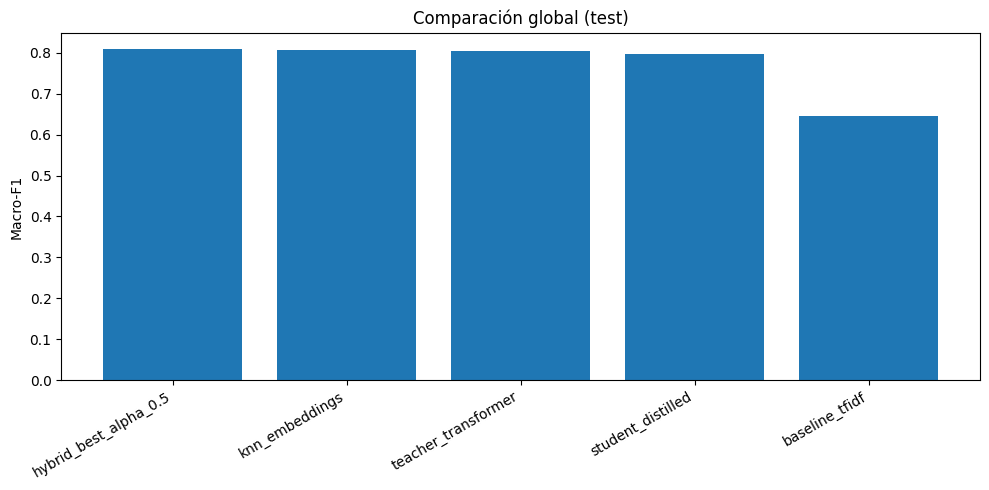

<Figure size 640x480 with 0 Axes>

In [55]:
models = [r["model"] for r in rows_sorted]
macro_f1s = [r["macro_f1"] for r in rows_sorted]

plt.figure(figsize=(10, 5))
plt.bar(models, macro_f1s)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro-F1")
plt.title("Comparación global (test)")
plt.tight_layout()
plt.show()

plt.savefig(FIGURES_DIR / "macro_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

| Modelo                  | Accuracy | Macro-F1 |
|-------------------------|----------|----------|
| Hybrid (α = 0.5)        | 0.808    | 0.809    |
| k-NN (embeddings)       | 0.806    | 0.806    |
| Teacher Transformer     | 0.803    | 0.804    |
| Student (destilado)     | 0.796    | 0.797    |
| Baseline (TF-IDF)       | 0.648    | 0.646    |


El análisis comparativo de los modelos en el conjunto de test muestra que las diferencias de rendimiento entre los enfoques basados en embeddings son reducidas, especialmente en términos de Macro-F1. Salvo el baseline TF-IDF, todos los modelos presentan resultados muy próximos, con variaciones inferiores a uno o dos puntos porcentuales.

El clasificador híbrido (α = 0.5) obtiene el mejor rendimiento global, aunque la mejora respecto al modelo Transformer teacher y al k-NN puro es moderada. Este comportamiento sugiere que la combinación de predicción paramétrica y recuperación de ejemplos aporta información complementaria, pero que ambos componentes ya son individualmente fuertes (al menos en estos experimentos), lo que limita el margen de mejora adicional.

El modelo k-NN sobre embeddings presenta un rendimiento prácticamente equivalente al Transformer completo. Esto indica que el espacio de embeddings generado por el modelo preentrenado captura de forma efectiva la estructura semántica del problema, permitiendo una clasificación competitiva incluso sin un clasificador paramétrico entrenado. Desde el punto de vista práctico, este resultado es relevante, ya que el k-NN ofrece una solución más simple e interpretable con un coste computacional reducido.

El modelo Transformer teacher ofrece un rendimiento sólido y estable, pero no destaca claramente frente a los métodos basados en recuperación. Esto podría deberse a que gran parte del rendimiento viene determinada por la calidad de los embeddings.

El modelo student destilado muestra una ligera reducción del rendimiento respecto al teacher, coherente con el proceso de destilación. No obstante, la caída en Macro-F1 es limitada.

En contraste, el baseline TF-IDF queda claramente por detrás del resto de modelos. Esta diferencia más notoria pone de manifiesto la importancia de las representaciones distribuidas para capturar relaciones semánticas complejas en textos musicales, algo que los enfoques basados únicamente en frecuencia de términos no consiguen modelar adecuadamente.

Como conclusión, aunque el modelo híbrido obtiene el mejor resultado, las diferencias entre los modelos basados en embeddings son pequeñas en este caso. En este contexto, la elección del modelo podría guiarse más por consideraciones de coste, interpretabilidad y facilidad de uso que por diferencias marginales de rendimiento.

### 7.2. Sesgo y ética
- Analizar aspectos de equidad y sesgo, como si hay clases peor tratadas o si los vecinos podrían agravar sesgos.

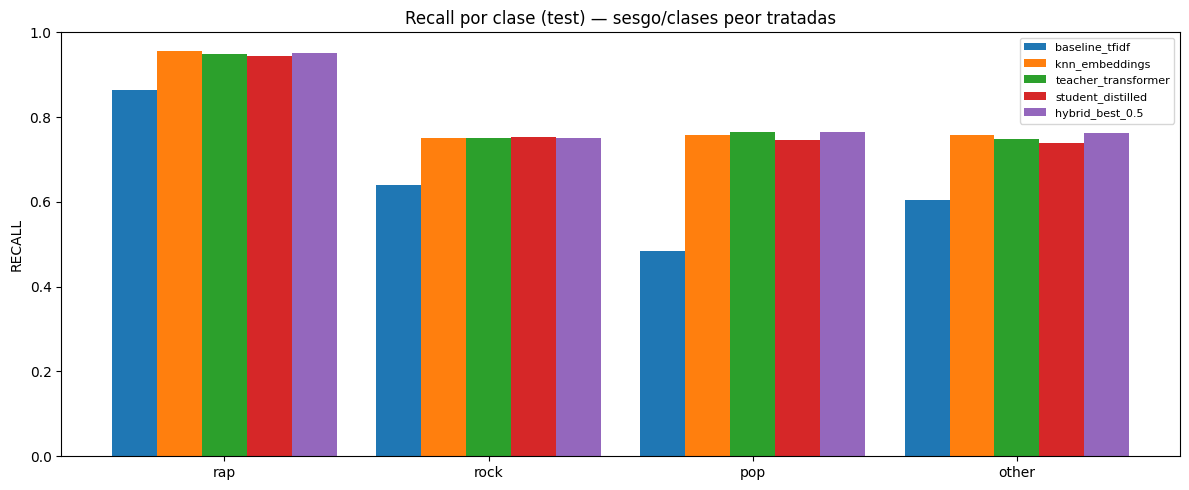

In [56]:
def recall_per_class(y_true, y_pred, nC):
    return recall_score(y_true, y_pred, average=None, labels=list(range(nC)), zero_division=0)

# modelos principales
preds_bias = {
    "baseline_tfidf": PRED_TEST["baseline_tfidf"],
    "knn_embeddings": PRED_TEST["knn_embeddings"],
    "teacher_transformer": PRED_TEST["teacher_transformer"],
    "student_distilled": PRED_TEST["student_distilled"],
}

# híbrido best alpha
if best_alpha is not None:
    preds_bias[f"hybrid_best_{best_alpha}"] = PRED_TEST["hybrid"][best_alpha]

# plot recall
models = list(preds_bias.keys())
nC = len(LABEL_NAMES)
mat = np.array([recall_per_class(y_test_baseline, preds_bias[m], nC) for m in models])

x = np.arange(nC)
width = 0.85 / len(models)
plt.figure(figsize=(12, 5))
for i, m in enumerate(models):
    plt.bar(x + i*width, mat[i], width=width, label=m)
plt.xticks(x + (len(models)-1)*width/2, LABEL_NAMES)
plt.ylim(0, 1)
plt.ylabel("RECALL")
plt.title("Recall por clase (test) — sesgo/clases peor tratadas")
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "recall_per_class.png", dpi=300, bbox_inches="tight")
plt.show()

El análisis del rendimiento por clase, mediante la métrica de Recall, revela diferencias sistemáticas entre las categorías, pero estas no parecen estar asociadas a sesgos discriminatorios, sino principalmente a la heterogeneidad interna de las clases y al grado de solapamiento semántico entre ellas.

La clase “rap” presenta valores de recall consistentemente elevados en todos los modelos evaluados. Este comportamiento puede explicarse por la presencia de rasgos léxicos y estilísticos muy característicos, como el uso de jerga específica, referencias explícitas y estructuras repetitivas, que facilitan su identificación incluso para modelos más simples.

Por el contrario, las clases “rock”, “pop” y “other” muestran valores de recall más bajos y cercanos entre sí. Estas categorías agrupan textos estilísticamente más diversos y con fronteras menos definidas, lo que incrementa la dificultad de clasificación. En particular, la clase other actúa como una categoría residual que engloba ejemplos muy heterogéneos, lo que podría estar limitando la capacidad de cualquier modelo para aprender patrones consistentes.

Los modelos basados en embeddings, especialmente el k-NN y el clasificador híbrido, logran mejorar parcialmente el recall de estas clases más complejas. Este efecto sugiere que la información semántica capturada en el espacio de embeddings resulta útil para resolver casos fronterizos, aunque no elimina por completo las dificultades derivadas de la diversidad interna de las clases.

El modelo student destilado presenta un comportamiento muy similar al del modelo teacher, con ligeras degradaciones en algunas clases. Estas diferencias no apuntan a un sesgo introducido por la destilación, sino a una pérdida limitada de capacidad para manejar clases con mayor variabilidad interna.

Desde una perspectiva ética, los resultados indican que el principal reto no reside en la presencia de sesgos sistemáticos hacia determinadas clases, sino en la definición y composición de las propias categorías. En este contexto, el análisis por clase resulta fundamental para distinguir entre problemas de equidad y limitaciones inherentes al diseño del conjunto de datos.

Como conclusión, las diferencias observadas entre clases se explican principalmente por su heterogeneidad y solapamiento semántico, más que por sesgos introducidos por los modelos. Por tanto, mejorar la equidad en este escenario pasaría por una redefinición más precisa de las clases o por estrategias de modelado que tengan en cuenta su diversidad interna, más que por cambios en el algoritmo de clasificación.

### 7.3. Utilidad de la explicabilidad y riesgos
- Reflexionar sobre la utilidad real de las explicaciones basadas en tokens/atributos (P1), ejemplos (*retrieval*) y explicaciones generativas (resumen).


El análisis de la explicabilidad en este trabajo se ha abordado desde tres enfoques complementarios: explicaciones basadas en atributos o tokens, explicaciones por ejemplos mediante recuperación (retrieval) y explicaciones generativas basadas en resúmenes automáticos por clase. Cada uno de estos métodos presenta ventajas específicas, pero también limitaciones relevantes desde el punto de vista práctico y ético.

Las explicaciones basadas en tokens o atributos, como las empleadas en la Práctica 1, resultan especialmente útiles en modelos lineales o basados en representaciones TF-IDF, donde la contribución de cada término a la predicción es directa y fácilmente interpretable. No obstante, su aplicabilidad disminuye en modelos basados en embeddings y Transformers, en los que la información se distribuye de forma más compleja y la interpretación a nivel de token pierde precisión semántica.

Las explicaciones por ejemplos, obtenidas mediante la recuperación de vecinos más cercanos, han demostrado ser especialmente intuitivas. Mostrar textos similares del conjunto de entrenamiento permite justificar una predicción de forma comprensible, tanto en casos correctamente clasificados como en errores. En los ejemplos analizados, este enfoque ha facilitado la identificación de confusiones sistemáticas entre clases, proporcionando una herramienta valiosa para el diagnóstico del comportamiento del modelo. Sin embargo, su fiabilidad depende directamente de la calidad y el equilibrio del conjunto de entrenamiento.

Las explicaciones generativas, basadas en la creación de resúmenes por clase a partir de pseudo-documentos, ofrecen una visión global del contenido predominante en cada categoría. En algunas clases, como rap o rock, los resúmenes generados capturan parcialmente rasgos estilísticos coherentes con el género, como el tono narrativo o el uso de lenguaje explícito. Sin embargo, en otras clases, como pop u other, los textos generados resultan confusos, con mezclas de estilos, repeticiones y contenido poco representativo.

Este comportamiento indica que el modelo generativo no construye una representación semántica estructurada de cada clase, sino que resume patrones frecuentes del pseudo-documento de entrada, lo que puede amplificar ruido y solapamientos presentes en los datos. Además, se observan problemas claros de alucinación, generación redundante y aparición de contenido explícito sin contextualización, lo que limita seriamente la fiabilidad de este tipo de explicaciones sin supervisión humana.

Desde el punto de vista ético, estos riesgos son especialmente relevantes. El uso de modelos generativos pequeños o comprimidos puede heredar y amplificar sesgos del modelo teacher, mientras que los métodos basados en recuperación pueden reforzar sesgos existentes al agrupar sistemáticamente textos similares, incluso cuando contienen contenido problemático. Por tanto, la adopción de técnicas de explicabilidad debe ir acompañada de una evaluación crítica de sus limitaciones y de mecanismos de control adecuados.

En definitiva, las explicaciones por ejemplos constituyen el enfoque más robusto y práctico en este contexto, mientras que las explicaciones generativas deberían considerarse únicamente como herramientas exploratorias. En este contexto, la explicabilidad no debería entenderse como un fin en sí mismo, sino como una herramienta de apoyo al análisis humano, orientada a facilitar la comprensión y trazabilidad de las decisiones del modelo, especialmente cuando se emplean modelos comprimidos o se trabaja con datos potencialmente sensibles.

In [57]:
if MEASURE_TIME:
    notebook_end = time.time()
    print(f"- Tiempo total de ejecución del notebook: {notebook_end - notebook_start:.3f} segundos.")

- Tiempo total de ejecución del notebook: 11187.329 segundos.
